### Import

In [315]:
import numpy as np
import scipy.ndimage as ndimage
import matplotlib.pyplot as plt
import os

### Load Img

In [316]:
# Use an absolute path to the image file
image_path = os.path.abspath('images/primer_0_pi_rad.png')
# image_path = os.path.abspath('images/forest_horison.jpg')

# Load the image
slika = plt.imread(image_path)[:, :, :3]

# Convert to grayscale by averaging the RGB channels
slika = slika.mean(2)

### Apply Gaussian filter

In [317]:
# Apply gaussian filter from ndimage library
slika_conv_gaussian = ndimage.gaussian_filter(slika, sigma=40)

# This guassian filter does not work as expected so I used a predefined one
"""
sigma = 1.0
velikost_jedra = int(3*sigma)
# koordinate jedra po x dimenziji
x = np.arange(-velikost_jedra, velikost_jedra+1)
# koordinate jedra v obeh dimenzijah v 2d matrikah
X, Y = np.meshgrid(x, x)
jedro_tocke = np.array([X.ravel(), Y.ravel()]) # 2 x P
C = np.eye(2)*1/sigma**2

jedro_gauss = np.exp(-1*(jedro_tocke.T.dot(C)*jedro_tocke.T).sum(1)).reshape(X.shape)

slika_conv_gaussian = ndimage.convolve(slika, jedro_gauss, mode='constant', cval=0.0)
plt.imshow(slika)
"""

"\nsigma = 1.0\nvelikost_jedra = int(3*sigma)\n# koordinate jedra po x dimenziji\nx = np.arange(-velikost_jedra, velikost_jedra+1)\n# koordinate jedra v obeh dimenzijah v 2d matrikah\nX, Y = np.meshgrid(x, x)\njedro_tocke = np.array([X.ravel(), Y.ravel()]) # 2 x P\nC = np.eye(2)*1/sigma**2\n\njedro_gauss = np.exp(-1*(jedro_tocke.T.dot(C)*jedro_tocke.T).sum(1)).reshape(X.shape)\n\nslika_conv_gaussian = ndimage.convolve(slika, jedro_gauss, mode='constant', cval=0.0)\nplt.imshow(slika)\n"

### Popraviti kote, ampak ne več

In [318]:
"""
f=np.zeros((31, 31))
f[0, 0] = 1

slika_filt = ndimage.convolve(slika_conv_gaussian, f, mode='constant', cval=0)
"""

"\nf=np.zeros((31, 31))\nf[0, 0] = 1\n\nslika_filt = ndimage.convolve(slika_conv_gaussian, f, mode='constant', cval=0)\n"

### Apply Sobel filter 
### Make magnitude

In [319]:
jedro_sobel_dx = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])
jedro_sobel_dy = np.array([
    [-1, -2, -1],
    [0,  0,  0],
    [1, 2, 1]
])

slika_dx = ndimage.convolve(slika_conv_gaussian, jedro_sobel_dx)
slika_dy = ndimage.convolve(slika_conv_gaussian, jedro_sobel_dy)
# slika_dx_and_dy = ndimage.convolve(slika_dx, jedro_sobel_dy, mode='constant', cval=0.0)
#"""
slika_rob_mag = (slika_dx**2 + slika_dy**2)**0.5 # samo pitagorov izrek
# slika_rob_smer = np.arctan2(slika_dy, slika_dx)
slika_rob_smer = np.arctan2(slika_dy, slika_dx)

# Apply Sobel filters to the image
slika_sobel_dx = ndimage.convolve(slika_conv_gaussian, jedro_sobel_dx)
slika_sobel_dy = ndimage.convolve(slika_conv_gaussian, jedro_sobel_dy)

# Compute the magnitude of the gradient
slika_sobel = np.hypot(slika_sobel_dx, slika_sobel_dy)

# Normalize the result
slika_sobel = (slika_sobel / slika_sobel.max()) * 255  # Scale to 0-255

# Convert to unsigned 8-bit integer type for proper image representation
slika_sobel = slika_sobel.astype(np.uint8)

### Make histogram
#### Apply magnitude to histogram as weights

In [320]:
# razdelimo histogram na 16 predalckov med vrednostmi -pi, pi
hist_bins = np.linspace(-np.pi, np.pi, 17)
# razdelimo piksle v predalcke po kotu roba, pomnozeno z weightom magnitude ki nam pove kak mocn je rob
# hist_smeri_x, hist_smeri_y = np.histogram(slika_sobel, bins=hist_bins, weights=slika_rob_mag)

# Tried both methods for edge detection but the results are not as expected
hist_smeri_x, hist_smeri_y = np.histogram(slika_rob_smer, bins=hist_bins, weights=slika_rob_mag)

## Print out angle

In [321]:
# Find the index of the maximum value
max_y_index = np.argmax(hist_smeri_x)

# Find the corresponding bin edge (x-axis)
max_x = hist_bins[max_y_index]

print(f"Maximum value on the x-axis (bin edge in rad): {max_x}")

# Find the second largest value in the histogram counts
sorted_hist_smeri_x = np.sort(hist_smeri_x)[::-1]  # Sort in descending order
second_largest_y = sorted_hist_smeri_x[1]  # Second largest value

# Find the corresponding bin edge for the second largest value
second_largest_y_index = np.where(hist_smeri_x == second_largest_y)[0][0]
second_largest_x = hist_bins[second_largest_y_index]

print(f"Second largest value on the x-axis (bin edge in rad): {second_largest_x}")

print(f"")
print(f"Maximum and second largest values in the histogram combined and devided by 2:")
print(f"Angle in rad: {(second_largest_x + max_x) * 0.5}")
print(f"Agle in degrees: {(second_largest_x + max_x) * 0.5 * 180 / np.pi}")

#max_y = x[np.where(hist_smeri_y == hist_smeri_y.max())]
#print(f"Maximum: {hist_bins[max_y]}")

Maximum value on the x-axis (bin edge in rad): 1.5707963267948966
Second largest value on the x-axis (bin edge in rad): 1.178097245096172

Maximum and second largest values in the histogram combined and devided by 2:
Angle in rad: 1.3744467859455343
Agle in degrees: 78.74999999999999


## Show histogram and filtered image

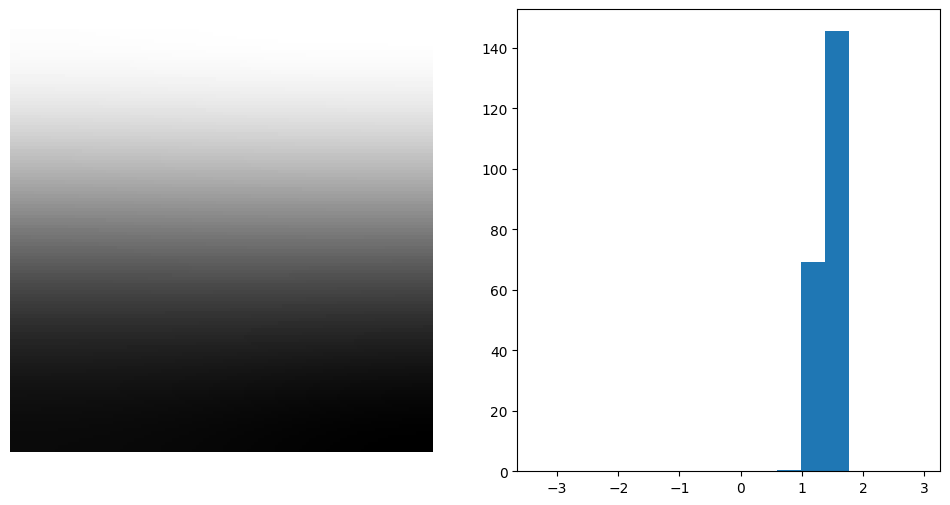

In [322]:
# Plot the image and histogram
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(slika_conv_gaussian, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
# 16 bins, count is height, width is the difference between two edges
plt.bar(hist_bins[:-1], hist_smeri_x, width=hist_bins[2] - hist_bins[1])

plt.show()

#### Old show graph code

In [323]:
"""
# Display the original and the blurred image
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title('Original img')
plt.imshow(slika, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Filtered img')
plt.imshow(slika_sobel, cmap='gray')
plt.axis('off')

plt.show()
"""

"\n# Display the original and the blurred image\nplt.figure(figsize=(12, 6))\n\nplt.subplot(1, 2, 1)\nplt.title('Original img')\nplt.imshow(slika, cmap='gray')\nplt.axis('off')\n\nplt.subplot(1, 2, 2)\nplt.title('Filtered img')\nplt.imshow(slika_sobel, cmap='gray')\nplt.axis('off')\n\nplt.show()\n"